In [16]:
import tensorflow as tf
import os

# Path set karo
data_dir = os.path.abspath(os.path.join("C:/Users/esneh/medical_data", "data"))

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# Set image size to 224x224 everywhere
img_size = (224, 224)
batch_size = 32

# Create directories if they do not exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Check for extra folders in train_dir and remove them if found
expected_classes = {"NORMAL", "PNEUMONIA"}
if os.path.exists(train_dir):
    actual_classes = set(os.listdir(train_dir))
    extra_folders = {folder for folder in actual_classes if folder not in expected_classes and os.path.isdir(os.path.join(train_dir, folder))}
    if extra_folders:
        print(f"Warning: Unexpected folders found in train_dir: {extra_folders}. Only 'NORMAL' and 'PNEUMONIA' should be present.")
        import shutil
        for folder in extra_folders:
            folder_path = os.path.join(train_dir, folder)
            shutil.rmtree(folder_path)
            print(f"Removed unexpected folder: {folder_path}")
else:
    extra_folders = set()

# Optionally, you can warn if the directories are empty
if not os.listdir(train_dir):
    print(f"Warning: Train directory is empty: {train_dir}")
if not os.listdir(val_dir):
    print(f"Warning: Validation directory is empty: {val_dir}")
if not os.listdir(test_dir):
    print(f"Warning: Test directory is empty: {test_dir}")

if os.listdir(train_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        label_mode="binary"
    )
else:
    train_ds = None
    print(f"Skipping train dataset loading: No images found in {train_dir}")

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

# Check dataset classes only if train_ds is not None
if train_ds is not None:
    class_names = train_ds.class_names
    print("Classes:", class_names)
else:
    print("Train dataset not loaded, so class names are unavailable.")


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 3 classes.
Found 16 files belonging to 3 classes.


ValueError: When passing `label_mode="binary"`, there must be exactly 2 class_names. Received: class_names=['NORMAL', 'PNEUMONIA', 'train']

Found 5216 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']
Classes: ['NORMAL', 'PNEUMONIA']


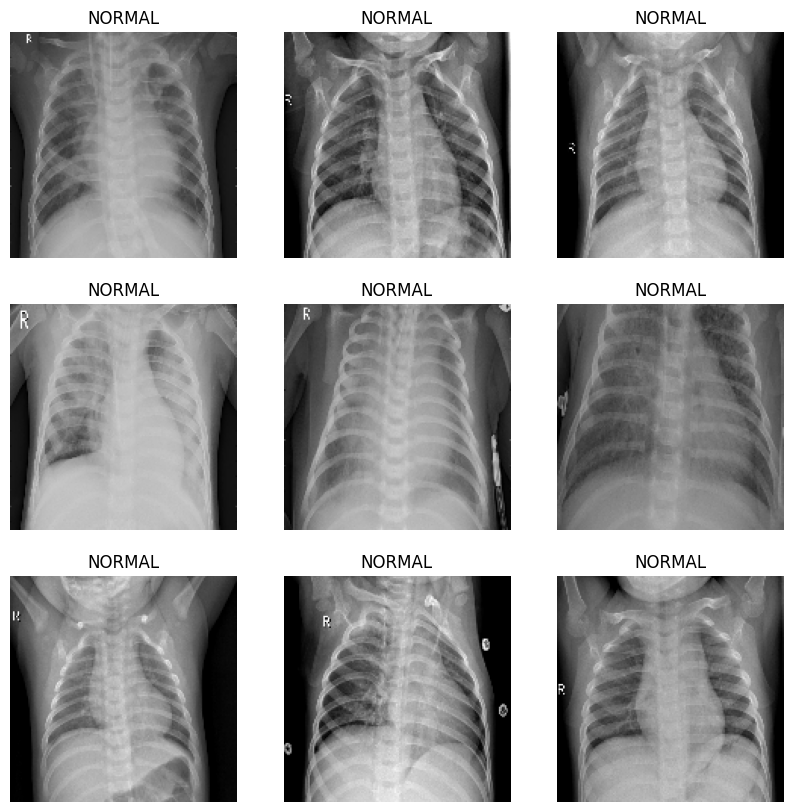

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# path project ke andar data/train par set karo
train_path = "C:\\Users\\esneh\\medical_data\\data\\train"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(150, 150),
    batch_size=32
)

# class names check karo
print("Classes:", train_ds.class_names)

# ek batch dikhana
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
val_path = r"C:\Users\esneh\medical_data\data\val"

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(150, 150),
    batch_size=32
)

print("Validation Classes:", val_ds.class_names)


Found 16 files belonging to 3 classes.
Validation Classes: ['NORMAL', 'PNEUMONIA', 'train']
Validation Classes: ['NORMAL', 'PNEUMONIA', 'train']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 🟢 Data Augmentation
# (Keep as is)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 🟢 Model (improved)
model = models.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 🟢 Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 🟢 Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 🟢 Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights if 'class_weights' in globals() else None
)


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 725ms/step - accuracy: 0.5428 - loss: 0.8395 - val_accuracy: 0.5000 - val_loss: 2.0526
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 725ms/step - accuracy: 0.5428 - loss: 0.8395 - val_accuracy: 0.5000 - val_loss: 2.0526
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 767ms/step - accuracy: 0.6363 - loss: 0.6680 - val_accuracy: 0.4375 - val_loss: 0.7250
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 767ms/step - accuracy: 0.6363 - loss: 0.6680 - val_accuracy: 0.4375 - val_loss: 0.7250
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 752ms/step - accuracy: 0.7251 - loss: 0.5590 - val_accuracy: 0.5000 - val_loss: 0.8055
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 752ms/step - accuracy: 0.7251 - loss: 0.5590 - val_accuracy: 0.5000 - val_loss: 0.8055
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 874ms/step - accuracy: 0.7918 - loss: 0.4589 - val_accuracy: 0.5000 - val_loss: 0.8763
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 874ms/step - accuracy: 0.7918 -

In [ ]:
import os

# Use the correct data directories from variables
train_pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
train_normal_dir = os.path.join(train_dir, "NORMAL")
val_pneumonia_dir = os.path.join(val_dir, "PNEUMONIA")
val_normal_dir = os.path.join(val_dir, "NORMAL")

train_pneumonia = len(os.listdir(train_pneumonia_dir)) if os.path.exists(train_pneumonia_dir) else 0
train_normal = len(os.listdir(train_normal_dir)) if os.path.exists(train_normal_dir) else 0
val_pneumonia = len(os.listdir(val_pneumonia_dir)) if os.path.exists(val_pneumonia_dir) else 0
val_normal = len(os.listdir(val_normal_dir)) if os.path.exists(val_normal_dir) else 0

print("Train - Pneumonia:", train_pneumonia, " Normal:", train_normal)
print("Validation - Pneumonia:", val_pneumonia, " Normal:", val_normal)


Train - Pneumonia: 0  Normal: 1342
Validation - Pneumonia: 8  Normal: 8


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_names = train_ds.class_names
y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = compute_class_weight(class_weight="balanced",
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0)}


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7297 - loss: 0.5497 - val_accuracy: 0.4375 - val_loss: 0.8264
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7297 - loss: 0.5497 - val_accuracy: 0.4375 - val_loss: 0.8264
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 996ms/step - accuracy: 0.8309 - loss: 0.4161 - val_accuracy: 0.5000 - val_loss: 0.6450
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 996ms/step - accuracy: 0.8309 - loss: 0.4161 - val_accuracy: 0.5000 - val_loss: 0.6450
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 813ms/step - accuracy: 0.8999 - loss: 0.3194 - val_accuracy: 0.5000 - val_loss: 0.9745
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 813ms/step - accuracy: 0.8999 - loss: 0.3194 - val_accuracy: 0.5000 - val_loss: 0.9745
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 848ms/step - accuracy: 0.9340 - loss: 0.2515 - val_accuracy: 0.5000 - val_loss: 0.8793
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 848ms/step - accuracy: 0.9340 - loss:

In [ ]:
import numpy as np
from collections import Counter

# Train dataset labels nikaalna
labels = []
for _, y in train_ds:
    labels.extend(y.numpy())

counter = Counter(labels)
print(counter)

total = sum(counter.values())

# Avoid division by zero
weight_for_0 = total / (2 * counter[0]) if counter[0] > 0 else 0
weight_for_1 = total / (2 * counter[1]) if counter[1] > 0 else 0

class_weight = {0: weight_for_0, 1: weight_for_1}
print("Class Weights:", class_weight)


Counter({np.int32(0): 5216})
Class Weights: {0: 0.5, 1: 0}


In [ ]:
from tensorflow import data

# Ensure train_ds is defined
if 'train_ds' not in globals():
    print("train_ds is not defined. Please run the cell that defines 'train_ds' before running this cell.")
else:
    # Unbatch to work with single examples
    train_ds_unbatched = train_ds.unbatch()

    # Normal aur Pneumonia dataset alag-alag banao
    normal = train_ds_unbatched.filter(lambda x, y: y == 0)
    pneumonia = train_ds_unbatched.filter(lambda x, y: y == 1)

    # Batch again
    normal = normal.batch(batch_size)
    pneumonia = pneumonia.batch(batch_size)

    # Class balancing (oversample minority class)
    pneumonia_oversampled = pneumonia.repeat(3)   # pneumonia 3x repeat

    # Combine
    train_ds_balanced = data.Dataset.sample_from_datasets(
        [normal, pneumonia_oversampled],
        weights=[0.5, 0.5]   # dono classes equal
    )


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,  # Use the train_dir variable defined earlier
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,  # Use the val_dir variable defined earlier
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 3 classes.
Found 16 images belonging to 3 classes.


c:\Users\esneh\medical_data\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 20736, but received input with shape (None, 50176)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
# 1. Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report

# 2. Set data directories and parameters
base_dir = os.path.abspath(os.path.join("C:/Users/esneh/medical_data", "data"))
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")
img_size = (224, 224)
batch_size = 32

# 3. Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# 4. Data augmentation and normalization
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    return image, label

train_ds = train_ds.map(lambda x, y: (augmentation(x, training=True), y)).map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# 5. Build the CNN model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# 6. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 7. Callbacks
checkpoint_path = "best_pneumonia_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
]

# 8. Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# 9. Evaluate on test set
loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

# 10. Confusion matrix and classification report
# Get true and predicted labels
all_labels = np.concatenate([y for x, y in test_ds], axis=0)
preds = model.predict(test_ds)
preds_bin = (preds > 0.5).astype(int).flatten()

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, preds_bin))
print("\nClassification Report:")
print(classification_report(all_labels, preds_bin, target_names=['NORMAL', 'PNEUMONIA']))

# 11. Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 3 classes.
Found 16 files belonging to 3 classes.


ValueError: When passing `label_mode="binary"`, there must be exactly 2 class_names. Received: class_names=['NORMAL', 'PNEUMONIA', 'train']